In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from sccnasim.utils.gcna import load_cnas

In [3]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [4]:
cna_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/analysis/pseudobulk'
chrom_anno_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/rdr/pseudobulk/data/chrom_arm_length.3col.tsv'

#in_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/simu/matrix/HCC3N_simu.gene.countmatrix.scDesign2Simulated.cna.h5ad'
#feature_label = 'super-gene'    # 'super-gene' or 'inter-gene'

in_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/simu/matrix/HCC3N_simu.intergene.countmatrix.scDesign2Simulated.cna.h5ad'
feature_label = 'inter-gene'    # 'super-gene' or 'inter-gene'

In [5]:
min_cells_per_gene = 3
min_gene_mean = 0.1

In [6]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-%s-' % feature_label

dpi = 300

# Prepare Data

## Generate annotation of gene CNA type

In [8]:
os.makedirs(out_dir, exist_ok = True)

In [9]:
cna = load_cnas(cna_fn)
cna

,chrom,start,end,clone,cn_ale0,cn_ale1,region
0,1,123400001,248956422,tumor,1,2,1:123400001-248956422
1,4,50000001,190214555,tumor,0,1,4:50000001-190214555
2,8,1,45200000,tumor,0,1,8:1-45200000
3,8,45200001,145138636,tumor,1,2,8:45200001-145138636
4,13,17700001,114364328,tumor,2,0,13:17700001-114364328
5,17,1,25100000,tumor,2,0,17:1-25100000


In [10]:
adata = ad.read_h5ad(in_fn)
adata

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 21215
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type'

In [11]:
adata.var['feature'] = adata.var['gene']

gene_anno = adata.var.copy()
gene_anno['gene_cna_type'] = 'Neutral'
gene_anno.loc[gene_anno['cna_type'] == 'gain', 'gene_cna_type'] = 'Gain'
gene_anno.loc[gene_anno['cna_type'] == 'loss', 'gene_cna_type'] = 'Loss'
gene_anno.loc[gene_anno['cna_type'] == 'loh', 'gene_cna_type'] = 'LOH'
gene_anno

,gene,chrom,start,end,region,cn0,cn1,cna_type,feature,gene_cna_type
0,1_0_29554,1,0,29554,NaN,NaN,NaN,NaN,1_0_29554,Neutral
1,1_31109_34554,1,31109,34554,NaN,NaN,NaN,NaN,1_31109_34554,Neutral
2,1_36081_65419,1,36081,65419,NaN,NaN,NaN,NaN,1_36081_65419,Neutral
3,1_71585_89295,1,71585,89295,NaN,NaN,NaN,NaN,1_71585_89295,Neutral
4,1_133723_139790,1,133723,139790,NaN,NaN,NaN,NaN,1_133723_139790,Neutral
...,...,...,...,...,...,...,...,...,...,...
21210,9_137217009_137217452,9,137217009,137217452,NaN,NaN,NaN,NaN,9_137217009_137217452,Neutral
21211,9_137219361_137220247,9,137219361,137220247,NaN,NaN,NaN,NaN,9_137219361_137220247,Neutral
21212,9_137221581_137224635,9,137221581,137224635,NaN,NaN,NaN,NaN,9_137221581_137224635,Neutral
21213,9_137226311_137227271,9,137226311,137227271,NaN,NaN,NaN,NaN,9_137226311_137227271,Neutral


In [12]:
gene_anno['gene_cna_type'].value_counts()

gene_cna_type
Neutral    17803
Gain        1609
Loss        1005
LOH          798
Name: count, dtype: int64

## Load adata files

In [13]:
scrs_normal = adata[adata.obs['cell_type'] == 'normal'].copy()
print(scrs_normal)

scrs_tumor = adata[adata.obs['cell_type'] == 'tumor'].copy()
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type', 'feature'
AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type', 'feature'


## Load chrom annotations

In [14]:
chrom_anno = pd.read_csv(chrom_anno_fn, sep = '\t')
chrom_anno

,chrom,q_arm_start,q_arm_end
0,1,123400000,248956422
1,2,93900000,242193529
2,3,90900000,198295559
3,4,50000000,190214555
4,5,48800000,181538259
5,6,59800000,170805979
6,7,60100000,159345973
7,8,45200000,145138636
8,9,43000000,138394717
9,10,39800000,133797422


# Get metrics

In [15]:
mv = get_gw_metrics_group(
    X_lst = [scrs_normal.X, scrs_tumor.X],
    X_names = ['scdrs_N', 'scdrs_T'],
    id_lst = [scrs_normal.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.281667,0.338996,2.067103,0.770000,scdrs_N,1_0_29554
1,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_31109_34554
2,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_36081_65419
3,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_71585_89295
4,0.088333,0.083863,3.278396,0.913333,scdrs_N,1_133723_139790
...,...,...,...,...,...,...
42425,0.046667,0.047822,4.686074,0.955000,scdrs_T,9_137217009_137217452
42426,0.046667,0.044489,4.519809,0.953333,scdrs_T,9_137219361_137220247
42427,0.073333,0.071289,3.640919,0.928333,scdrs_T,9_137221581_137224635
42428,0.050000,0.057500,4.795828,0.955000,scdrs_T,9_137226311_137227271


In [16]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [17]:
pairs = [
    ("scdrs_T", "scdrs_N"),
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [18]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
genes = mv.loc[mv['group'] == 'scdrs_N', 'feature'].to_numpy()
st_log2fc['gene'] = np.tile(genes, int(st_log2fc.shape[0] / len(genes)))
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

             x        y    mean_x    mean_y    log2FC                   gene
0      scdrs_N  scdrs_T  0.281667  0.296667  0.074854              1_0_29554
1      scdrs_N  scdrs_T  0.000000  0.000000  0.000000          1_31109_34554
2      scdrs_N  scdrs_T  0.000000  0.000000  0.000000          1_36081_65419
3      scdrs_N  scdrs_T  0.000000  0.000000  0.000000          1_71585_89295
4      scdrs_N  scdrs_T  0.088333  0.076667 -0.204358        1_133723_139790
...        ...      ...       ...       ...       ...                    ...
21210  scdrs_N  scdrs_T  0.063333  0.046667 -0.440573  9_137217009_137217452
21211  scdrs_N  scdrs_T  0.061667  0.046667 -0.402099  9_137219361_137220247
21212  scdrs_N  scdrs_T  0.063333  0.073333  0.211504  9_137221581_137224635
21213  scdrs_N  scdrs_T  0.056667  0.050000 -0.180572  9_137226311_137227271
21214  scdrs_N  scdrs_T  0.070000  0.043333 -0.691878  9_137229638_137230757

[21215 rows x 6 columns]


# Filter genes

In [19]:
seed_normal = scrs_normal

mv_seed = mv.loc[mv['group'] == 'scdrs_N'].copy()
mv_seed['gene'] = mv_seed['feature']
mv_seed

,mean,var,cv,zero_prop,group,feature,gene
0,0.281667,0.338996,2.067103,0.770000,scdrs_N,1_0_29554,1_0_29554
1,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_31109_34554,1_31109_34554
2,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_36081_65419,1_36081_65419
3,0.000000,0.000000,0.000000,1.000000,scdrs_N,1_71585_89295,1_71585_89295
4,0.088333,0.083863,3.278396,0.913333,scdrs_N,1_133723_139790,1_133723_139790
...,...,...,...,...,...,...,...
21210,0.063333,0.062655,3.952274,0.938333,scdrs_N,9_137217009_137217452,9_137217009_137217452
21211,0.061667,0.057864,3.900810,0.938333,scdrs_N,9_137219361_137220247,9_137219361_137220247
21212,0.063333,0.062655,3.952267,0.938333,scdrs_N,9_137221581_137224635,9_137221581_137224635
21213,0.056667,0.063456,4.445383,0.946667,scdrs_N,9_137226311_137227271,9_137226311_137227271


In [20]:
n_cell = seed_normal.shape[0]
cutoff = 1 - min_cells_per_gene / n_cell
print(cutoff)
flag = mv_seed['zero_prop'] >= cutoff
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d)" % (n_gene, min_cells_per_gene))

0.995
10510 genes will be excluded (min_cells_per_gene = 3)


In [21]:
flag = mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_gene_mean = %f)" % (n_gene, min_gene_mean))

20274 genes will be excluded (min_gene_mean = 0.100000)


In [22]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d; min_gene_mean = %f)" % (n_gene, min_cells_per_gene, min_gene_mean))

20274 genes will be excluded (min_cells_per_gene = 3; min_gene_mean = 0.100000)


In [23]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
valid_genes = mv_seed.loc[~flag, 'feature'].to_numpy()
valid_genes.shape

(941,)

In [24]:
st_log2fc_valid = st_log2fc.loc[st_log2fc['gene'].isin(valid_genes)].copy()
st_log2fc_valid = st_log2fc_valid.merge(gene_anno, on = 'gene', how = 'left')
st_log2fc_valid

,x,y,mean_x,mean_y,log2FC,gene,chrom,start,end,region,cn0,cn1,cna_type,feature,gene_cna_type
0,scdrs_N,scdrs_T,0.281667,0.296667,0.074854,1_0_29554,1,0,29554,NaN,NaN,NaN,NaN,1_0_29554,Neutral
1,scdrs_N,scdrs_T,0.321667,0.268333,-0.261540,1_161525_358857,1,161525,358857,NaN,NaN,NaN,NaN,1_161525_358857,Neutral
2,scdrs_N,scdrs_T,0.175000,0.143333,-0.287981,1_451697_587629,1,451697,587629,NaN,NaN,NaN,NaN,1_451697_587629,Neutral
3,scdrs_N,scdrs_T,289.454987,285.878326,-0.017938,1_594768_685679,1,594768,685679,NaN,NaN,NaN,NaN,1_594768_685679,Neutral
4,scdrs_N,scdrs_T,0.303333,0.330000,0.121562,1_686673_760911,1,686673,760911,NaN,NaN,NaN,NaN,1_686673_760911,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,scdrs_N,scdrs_T,0.101667,0.068333,-0.573185,9_131558620_131576770,9,131558620,131576770,NaN,NaN,NaN,NaN,9_131558620_131576770,Neutral
937,scdrs_N,scdrs_T,11.845000,11.671667,-0.021268,9_132991687_133030675,9,132991687,133030675,NaN,NaN,NaN,NaN,9_132991687_133030675,Neutral
938,scdrs_N,scdrs_T,0.181667,0.151667,-0.260390,9_133575519_133578415,9,133575519,133578415,NaN,NaN,NaN,NaN,9_133575519_133578415,Neutral
939,scdrs_N,scdrs_T,0.103333,0.073333,-0.494765,9_133659344_133663560,9,133659344,133663560,NaN,NaN,NaN,NaN,9_133659344_133663560,Neutral


# Plot RDR signals

In [25]:
chr_info = {}
for i in range(chrom_anno.shape[0]):
    chr_info[str(chrom_anno['chrom'].iloc[i])] = (
        chrom_anno['q_arm_end'].iloc[i],
        chrom_anno['q_arm_start'].iloc[i]
    )
chr_info

{'1': (248956422, 123400000),
 '2': (242193529, 93900000),
 '3': (198295559, 90900000),
 '4': (190214555, 50000000),
 '5': (181538259, 48800000),
 '6': (170805979, 59800000),
 '7': (159345973, 60100000),
 '8': (145138636, 45200000),
 '9': (138394717, 43000000),
 '10': (133797422, 39800000),
 '11': (135086622, 53400000),
 '12': (133275309, 35500000),
 '13': (114364328, 17700000),
 '14': (107043718, 17200000),
 '15': (101991189, 19000000),
 '16': (90338345, 36800000),
 '17': (83257441, 25100000),
 '18': (80373285, 18500000),
 '19': (58617616, 26200000),
 '20': (64444167, 28100000),
 '21': (46709983, 12000000),
 '22': (50818468, 15000000)}

In [26]:
def plot_rdr(st_log2fc, out_fn, figsize = (10, 1), dpi = 300):
    chr_list = list(chr_info.keys())
    x_total = 0
    chr_bounds = {}
    arm_bounds = []
    gap = 1e7      # otherwise, points could overlap bound lines.
    fontsize = 7

    for chr_num in chr_list:
        len_chr, cen_pos = chr_info[chr_num]
        p_start = x_total
        q_start = x_total + cen_pos + gap
        chr_end = x_total + len_chr + gap*2
        chr_bounds[chr_num] = (p_start, q_start, chr_end)
        arm_bounds.append(q_start)
        x_total = chr_end

    color_dict = {
        "Gain": "#D14050",
        "Loss": "#0078BB",
        "LOH": "#40B5A8",
        "Neutral": '#B3B3B3'
    }

    df = pd.DataFrame(data = {
        'chr': st_log2fc['chrom'].astype(str),
        'x': (st_log2fc['start'] + st_log2fc['end']) / 2.0,
        'log2FC': st_log2fc['log2FC'],
        'cnv_state': st_log2fc['gene_cna_type']
    })
    for chr_num in chr_list:
        df.loc[df['chr'] == chr_num, 'x'] += chr_bounds[chr_num][0] + gap

    # Plot
    fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = dpi)

    ax.axhline(0, color = 'black', lw = 1, ls = '--', alpha = 0.7)
    for chr_num in chr_list:    # Chromosome and arm borders
        ax.axvline(chr_bounds[chr_num][0], color = "#bbbbbb", lw = 1.0, zorder = 0)
    for pos in arm_bounds:
        ax.axvline(pos, color = "#e0e0e0", lw = 0.5, ls = '--', zorder = 0)

    # Neutral genes
    pointsize = 2
    neu = df[df.cnv_state == "Neutral"]
    sns.scatterplot(
        data = neu, x = "x", y = "log2FC", 
        color = color_dict["Neutral"], s = pointsize, alpha = 0.9, 
        ax = ax, zorder = 1
    )
    # CNA genes
    for state in ["Gain", "Loss", "LOH"]:
        sub = df[df.cnv_state == state]
        sns.scatterplot(
            data = sub, x = "x", y = "log2FC", color = color_dict[state], 
            s = pointsize, alpha = 0.9, 
            ax = ax, zorder = 2
        )
    # Median line.
    for chr_num in chr_list:
        sub = df.loc[(df.chr == chr_num) & (df.x < chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)
        sub = df.loc[(df.chr == chr_num) & (df.x >= chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)

    markersize = fontsize - 1.5
    legend_elements = [
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Gain"], 
               markersize = markersize, label = 'Gain'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Loss"], 
               markersize = markersize, label = 'Loss'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["LOH"], 
               markersize = markersize, label = 'LOH'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Neutral"], 
               markersize = markersize, label = 'Neutral')
    ]
    fig.legend(
        handles = legend_elements, loc = "center left", bbox_to_anchor = (0.975, 0.5), 
        frameon = False, fontsize = fontsize, handletextpad = 0.1)

    for ax in [ax]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    ax.set_xlabel(None)
    ax.set_ylabel(r"Log$_2$FC", fontsize = fontsize)
    ax.set_xticks([(v[0]+v[2])/2 for v in chr_bounds.values()])
    ax.set_xticklabels([str(c) for c in chr_list], fontsize = fontsize)
    ax.tick_params(axis = 'x', length = 0)
    ax.set_xlim(0, chr_bounds['22'][-1])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize - 1
    )

    plt.tight_layout()
    fig.savefig(out_fn, dpi = dpi, bbox_inches = 'tight')

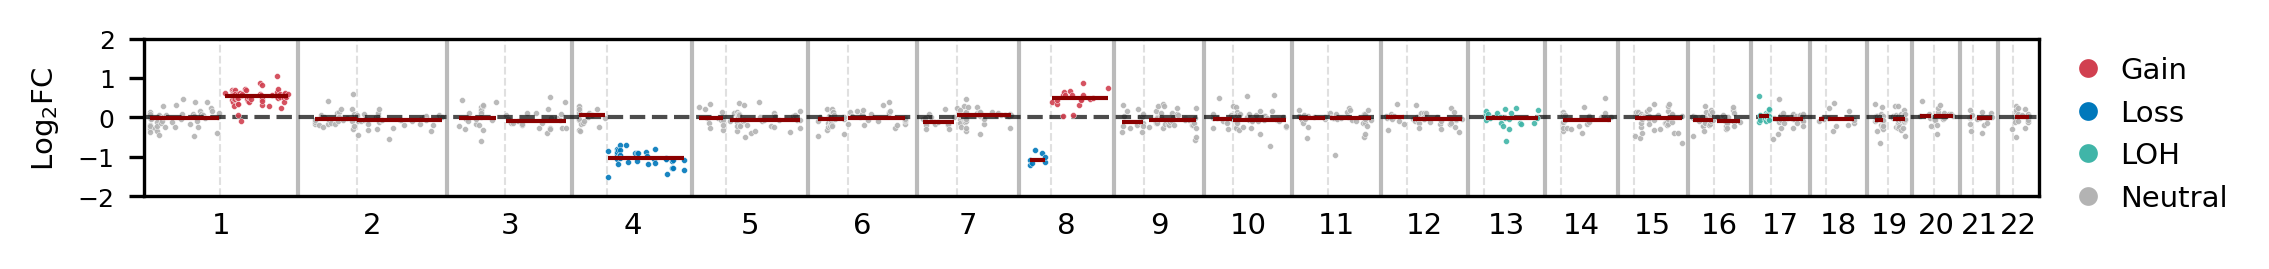

In [27]:
st_log2fc = st_log2fc_valid.loc[st_log2fc_valid['x'] == 'scdrs_N'].copy()
fn = os.path.join(out_dir, gw_prefix + "rdr-pseudobulk.png")
plot_rdr(st_log2fc, out_fn = fn, figsize = (7, 1))